In [1]:
import os
import sys
import random
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import mlflow

import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16') # !!!
from tensorflow.keras import Model, Sequential, layers
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten 

2026-04-14 10:43:38.908394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 10:43:38.926301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776156218.945981     495 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776156218.951698     495 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776156218.967736     495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
sys.stderr = open(os.devnull, "w")

I0000 00:00:1776156233.841044     495 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:2a:00.0, compute capability: 8.9
I0000 00:00:1776156384.758419     495 cuda_dnn.cc:529] Loaded cuDNN version 90500
2026-04-14 10:49:16.002766: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 13 of 256
2026-04-14 10:49:19.677442: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
2026-04-14 10:49:19.677845: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-14 10:49:31.870043: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 15 of 256
2026-04-14 10:49:34.785533: I tensorflow/core/kernels/data/shuffle_dataset_op.

# Dataloading

In [3]:
notebook_dir = Path().resolve()  # current working directory
parent_dir = notebook_dir.parent
sys.path.insert(0, str(parent_dir))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator

from utils.augmentations import PromptUNetAugmenter
augmenter = PromptUNetAugmenter()

from utils.metrics import dice_score_tf
from utils.visualization import plot_result

In [4]:
datagenerator = DataGenerator(DataLoader_npz(["data/train_data/nako_combined.npz", "data/train_data/total_seg_combined.npz", "data/train_data/msd_combined.npz"], val_size=0.015))


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.



# Prompt U-Net

In [5]:
epochs = 4000
batch_size = 128
dp_training = 3500 

from optimizer import PromptUNetOptimizer
opt_config = PromptUNetOptimizer(epochs=epochs, batch_size=batch_size, dp_training=dp_training)


In [6]:
from prompt_unet import PromptUNet
model = PromptUNet()

# 1. Define the base optimizer
model.optimizer = opt_config.get_optimizer()
dummy_input = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
dummy_prompt = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([dummy_input, dummy_prompt])

# Training

In [7]:
offset = 12
max_number_labels = 4

dp_training = 3500
dp_testing = 1000

new_ds = 75 # Every x Epochs a new DS is generated
new_val_loop = 300 # Every x Epochs the validation loop is performed

version = 'p_unet_291'

Creating new Data Points ...
It took 27 seconds


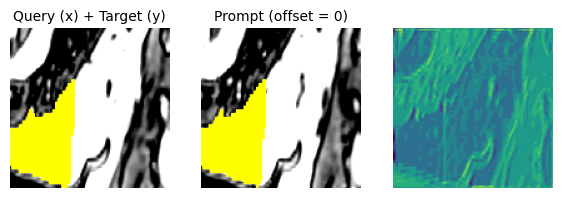

Creating new Data Points ...
It took 129 seconds
Epoch 1, Loss: 0.0, 
Epoch 2, Loss: 0.0, 
Epoch 3, Loss: 0.0, 
Epoch 4, Loss: 0.0, 
Epoch 5, Loss: 0.0, 
Epoch 6, Loss: 0.0, 
Epoch 7, Loss: 0.0, 
Epoch 8, Loss: 0.0, 
Epoch 9, Loss: 0.0, 
Epoch 10, Loss: 0.0, 
Epoch 11, Loss: 0.0, 
Epoch 12, Loss: 0.0, 
Epoch 13, Loss: 0.0, 


In [ ]:
from IPython.display import clear_output

def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run() as run:
        
        # Log hyperparameters
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("max_number_labels", max_number_labels)
        mlflow.log_param("num_epochs", epochs)
        mlflow.log_param("loss_function", "binary_crossentropy")
        
        test_ds, _ = datagenerator.get_val_data_points(max_data_points=dp_testing, 
        offset=offset, max_number_labels=max_number_labels)
     
        test_ds = test_ds.batch(1)
        
        for epoch in range(epochs):  
            # --- Log Lr ---
            current_lr = model.optimizer.learning_rate
            
            if isinstance(current_lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                current_lr = current_lr(epoch)  # evaluate schedule at current epoch
            else:
                current_lr = current_lr.numpy()  # constant value

            mlflow.log_metric("learning_rate", float(current_lr), step=epoch)
            
            model.train_loss.reset_state()

            if epoch%8==0 and epoch != 0:
                
                model_name = f'{version}.keras'
                model.this.save(model_name)
                
            # Validation Loop
            if epoch%new_val_loop==0 and epoch != 0:
                
                total_dice = 0

                for z in test_ds:
                    val_pred = model.this([z[0], z[2]], training=False)
                    total_dice += dice_score_tf(z[1][...,0:1], val_pred)

                total_dice /= dp_testing
                mlflow.log_metric("validation_loss", 1-total_dice, step=epoch)
                print('Validation loss:', str(1-total_dice))

                
            # Pull new random Train Dataset (every x epochs because create_prompt takes some time)
            if epoch%new_ds==0:
                
                # Plot pred for first x examples of val ds
                z_test = next(iter(test_ds))

                pred = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], 0, "")
                
                # New Ds
                # Clear old dataset first to free memory before allocating new one
                if 'train_ds' in locals():
                    del train_ds
                    import gc
                    gc.collect()
                train_ds, offset_train = datagenerator.get_data_points(max_data_points=dp_training, 
                offset=offset, max_number_labels=max_number_labels)      
                
                # Map pipeline ONCE here instead of every epoch in train_epoch
                train_ds = train_ds.shuffle(256) \
                .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE) \
                .batch(batch_size, drop_remainder=True) \
                .prefetch(tf.data.AUTOTUNE)
                    
            model.train_epoch(train_dataset=train_ds)  # don't batch, because train_ds is already batched    

            # Display & log metrics at the end of each epoch
            print(f'Epoch {epoch + 1}, '
                  f'Loss: {model.train_loss.result()}, ')
            mlflow.log_metric("train_loss", model.train_loss.result(), step=epoch)

fit(epochs)   